# 00 — Persistence check (CLAUDE.md §5.1)

Go/no-go on the method's central premise: a clade must persist across many
marginal trees as one node id (delivered natively by msprime/tsinfer, or by
Relate `Convert --compress`). If `frac_singletons` is near 1 the premise is not
met; real mass above 1 means the horizontal coupling has signal.

In [1]:
import tslai

ts = tslai.simulate_admixture(n_admix=10, n_ref=10, sequence_length=5e6,
                              recombination_rate=1e-8, random_seed=1)
print('trees:', ts.num_trees, 'nodes:', ts.num_nodes, 'edges:', ts.num_edges)
print('persistence:', tslai.diagnostics.persistence_summary(ts))
print('edge spans:', tslai.diagnostics.edge_span_summary(ts))

trees: 9964 nodes: 6442 edges: 35687


persistence: {'median': 30.0, 'max': 9964, 'frac_singletons': 0.05468505170792855, 'n_internal': 6382}
edge spans: {'median': 4611.0, 'mean': 24850.858968251745, 'min': 1.0, 'max': 5000000.0, 'n_edges': 35687}


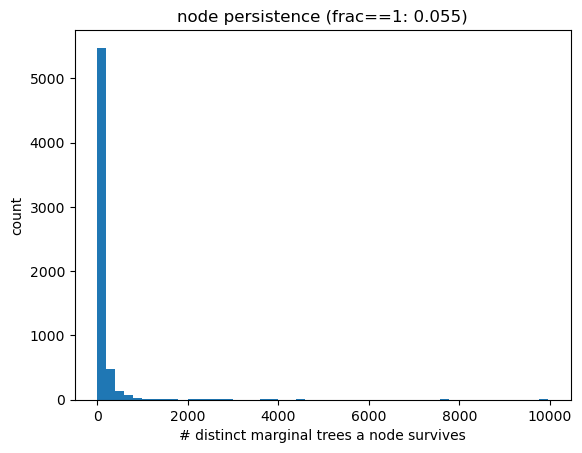

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

counts = tslai.diagnostics.node_persistence(ts)
plt.hist(counts, bins=50)
plt.xlabel('# distinct marginal trees a node survives')
plt.ylabel('count')
plt.title(f'node persistence (frac==1: {np.mean(counts==1):.3f})')
plt.show()